In [ ]:
!pip install pymatgen matminer xgboost lightgbm catboost --quiet

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [ ]:
# load reactions
with open("reactions_clean.json") as f:
    reactions = json.load(f)

print(f"Loaded {len(reactions)} reactions.")

Loaded 330 reactions.


In [ ]:
# get unique compounds from reactants and products
compounds = set()
for r in reactions:
    compounds.update(r["reactants"].keys())
    compounds.update(r["products"].keys())

compounds = sorted(compounds)
compounds_df = pd.DataFrame({"formula": compounds})
compounds_df.to_csv("compounds.csv", index=False)
print(f"Unique compounds: {len(compounds)}")

Unique compounds: 266


In [ ]:
# featurize using magpie descriptors
compounds_df["composition"] = compounds_df["formula"].apply(Composition)

ep = ElementProperty.from_preset("magpie")
features_df = ep.featurize_dataframe(compounds_df, col_id="composition", ignore_errors=True)
features_df.set_index("formula", inplace=True)
features_only = features_df.drop(columns=["composition"], errors="ignore")

print(f"Feature matrix shape: {features_only.shape}")

ElementProperty:   0%|          | 0/266 [00:00<?, ?it/s]

Feature matrix shape: (266, 132)


In [ ]:
# extract targets
Teq    = [rxn["Teq"]    for rxn in reactions]
DeltaH = [rxn["DeltaH"] for rxn in reactions]

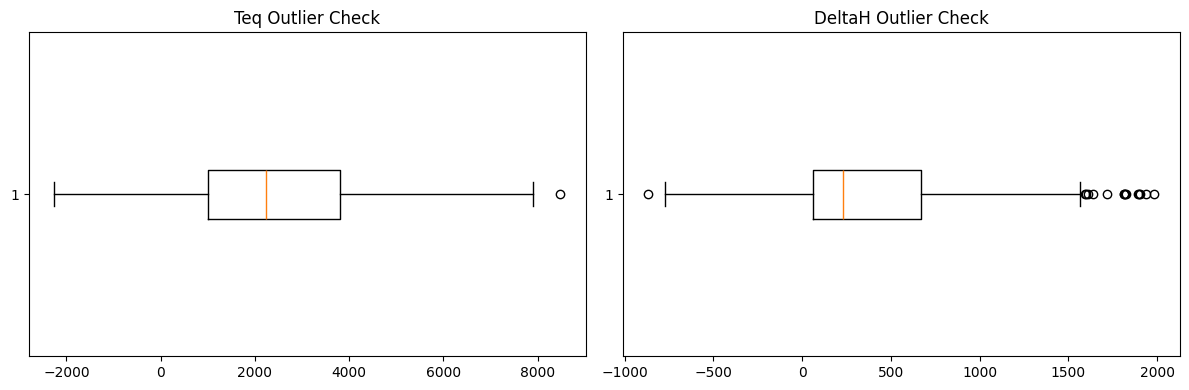

In [ ]:
# boxplots to check for outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(Teq, vert=False)
axes[0].set_title("Teq Outlier Check")
axes[1].boxplot(DeltaH, vert=False)
axes[1].set_title("DeltaH Outlier Check")
plt.tight_layout()
plt.show()

In [ ]:
# build one feature vector per reaction by summing coeff * compound_features
rxn_vectors = []
skipped = 0

for r in reactions:
    try:
        rxn_vec = np.zeros(features_only.shape[1])
        for comp, coeff in r["reactants"].items():
            rxn_vec += coeff * features_only.loc[comp].values
        for comp, coeff in r["products"].items():
            rxn_vec += coeff * features_only.loc[comp].values
        rxn_vectors.append(rxn_vec)
    except KeyError:
        skipped += 1

print(f"Vectors created: {len(rxn_vectors)}, skipped: {skipped}")

Vectors created: 330, skipped: 0


In [ ]:
# scale features and targets
X = np.array(rxn_vectors)

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_T = StandardScaler()
y_T_scaled = scaler_T.fit_transform(np.array(Teq).reshape(-1, 1)).ravel()

scaler_H = StandardScaler()
y_H_scaled = scaler_H.fit_transform(np.array(DeltaH).reshape(-1, 1)).ravel()



In [ ]:
# train/test split
X_train, X_test, yT_train, yT_test, yH_train, yH_test = train_test_split(
    X_scaled, y_T_scaled, y_H_scaled, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")



Train: 264, Test: 66


In [ ]:
# helper to train, evaluate and store results
results = {}

def train_and_evaluate(name, model, X_tr, y_tr, X_te, y_te, scaler):
    model.fit(X_tr, y_tr)
    pred_scaled = model.predict(X_te)
    r2  = r2_score(y_te, pred_scaled)
    mse = mean_squared_error(y_te, pred_scaled)
    pred_orig = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    true_orig = scaler.inverse_transform(y_te.reshape(-1, 1)).ravel()
    mae = mean_absolute_error(true_orig, pred_orig)
    print(f"\n{name}  |  R²: {r2:.4f}  |  MSE: {mse:.4f}  |  MAE: {mae:.4f}")
    results[name] = {"r2": r2, "mse": mse}
    return model


In [ ]:
# Random Forest - DeltaH
model_rf_H = train_and_evaluate(
    "Random Forest",
    RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    X_train, yH_train, X_test, yH_test, scaler_H
)



Random Forest  |  R²: 0.4721  |  MSE: 0.3580  |  MAE: 222.3383


In [ ]:
# Random Forest - Teq (separate, not included in DeltaH comparison)
model_rf_T = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)
model_rf_T.fit(X_train, yT_train)
pred_T = model_rf_T.predict(X_test)
print(f"\nRandom Forest Teq  |  R²: {r2_score(yT_test, pred_T):.4f}  |  MSE: {mean_squared_error(yT_test, pred_T):.4f}")

# XGBoost - DeltaH
model_xgb = train_and_evaluate(
    "XGBoost",
    XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        min_child_weight=1, subsample=0.8, colsample_bytree=0.8,
        gamma=0, reg_alpha=0, reg_lambda=1, random_state=42, n_jobs=-1
    ),
    X_train, yH_train, X_test, yH_test, scaler_H
)


Random Forest Teq  |  R²: 0.2626  |  MSE: 0.5815

XGBoost  |  R²: 0.4662  |  MSE: 0.3621  |  MAE: 222.3632


In [ ]:
# LightGBM - DeltaH
model_lgbm = train_and_evaluate(
    "LightGBM",
    LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=-1,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    ),
    X_train, yH_train, X_test, yH_test, scaler_H
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5703
[LightGBM] [Info] Number of data points in the train set: 264, number of used features: 126
[LightGBM] [Info] Start training from score 0.037374
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# CatBoost - DeltaH
model_cat = train_and_evaluate(
    "CatBoost",
    CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        loss_function="RMSE", random_seed=42, verbose=0
    ),
    X_train, yH_train, X_test, yH_test, scaler_H
)


CatBoost  |  R²: 0.5235  |  MSE: 0.3232  |  MAE: 214.0445


In [ ]:
# HistGradientBoosting - DeltaH
model_hgb = train_and_evaluate(
    "HistGradientBoosting",
    HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, max_depth=None,
        min_samples_leaf=20, random_state=42
    ),
    X_train, yH_train, X_test, yH_test, scaler_H
)


HistGradientBoosting  |  R²: 0.3477  |  MSE: 0.4424  |  MAE: 242.2222


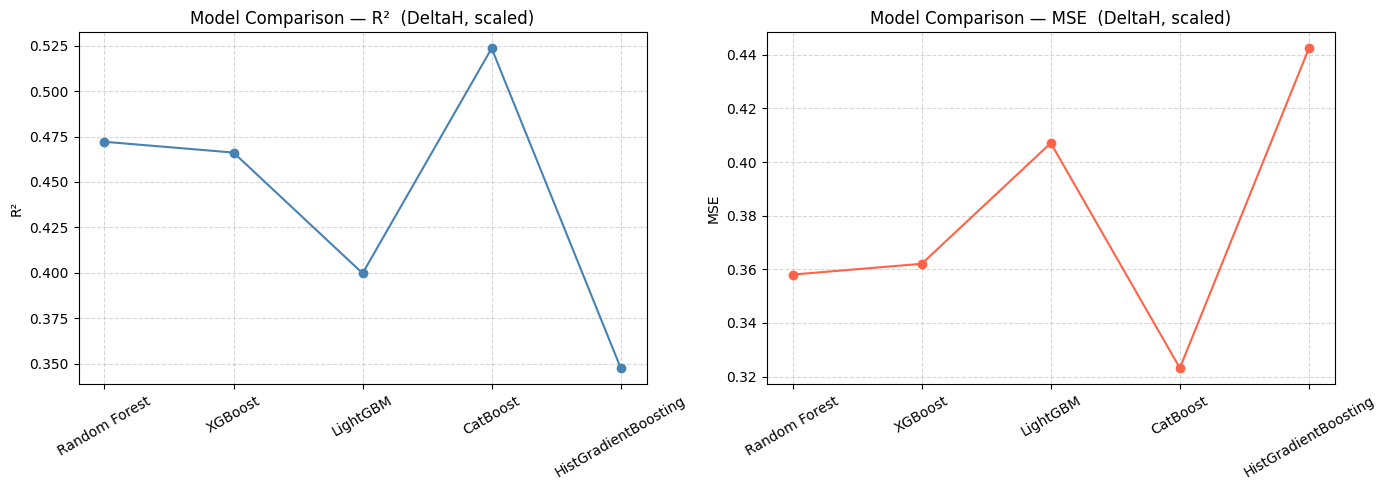

In [ ]:
# comparison plot using auto-collected results
model_names = list(results.keys())
r2_scores  = [results[m]["r2"]  for m in model_names]
mse_scores = [results[m]["mse"] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_names, r2_scores, marker="o", color="steelblue")
axes[0].set_title("Model Comparison — R²  (DeltaH, scaled)")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(model_names, mse_scores, marker="o", color="tomato")
axes[1].set_title("Model Comparison — MSE  (DeltaH, scaled)")
axes[1].set_ylabel("MSE")
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:

# summary table
print(f"\n{'Model':<25} {'R²':>8} {'MSE':>8}")
print("-" * 43)
for m in model_names:
    print(f"{m:<25} {results[m]['r2']:>8.4f} {results[m]['mse']:>8.4f}")

best = max(results, key=lambda m: results[m]["r2"])
print(f"\nBest: {best}  |  R²: {results[best]['r2']:.4f}  |  MSE: {results[best]['mse']:.4f}")


Model                           R²      MSE
-------------------------------------------
Random Forest               0.4721   0.3580
XGBoost                     0.4662   0.3621
LightGBM                    0.3998   0.4071
CatBoost                    0.5235   0.3232
HistGradientBoosting        0.3477   0.4424

Best: CatBoost  |  R²: 0.5235  |  MSE: 0.3232
